# Proyek Klasifikasi Gambar: [Shoe vs Sandal vs Boot Image Dataset (15K Images)]
- **Nama:** [Biki Nurul Af'ida]
- **Email:** [bikinurul664@gmail.com]
- **ID Dicoding:** [MC001D5X2054]

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import random
import cv2

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

2025-04-29 08:53:25.677888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745916805.920707      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745916805.991036      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.18.0


## Data Preparation

### Data Loading

In [3]:
# This Python 3 environment comes with ma6ny helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/screenshot-2025-04-28-222702-png/Screenshot 2025-04-28 222702.png
/kaggle/input/screenshot-2025-04-28-225640-png/Screenshot 2025-04-28 225640.png
/kaggle/input/screenshot-2025-04-28-224951-png/Screenshot 2025-04-28 224951.png
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (4).jpg
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (1420).jpg
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (2254).jpg
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (616).jpg
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (3561).jpg
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (1045).jpg
/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe/Shoe (2596).jpg
/kaggle/

In [4]:
# Baca semua gambar dari folder 'Shoe'
shoe_folder = '/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Shoe'

shoe_images = os.listdir(shoe_folder)  
print(shoe_images)

['Shoe (4).jpg', 'Shoe (1420).jpg', 'Shoe (2254).jpg', 'Shoe (616).jpg', 'Shoe (3561).jpg', 'Shoe (1045).jpg', 'Shoe (2596).jpg', 'Shoe (234).jpg', 'Shoe (1464).jpg', 'Shoe (3494).jpg', 'Shoe (1213).jpg', 'Shoe (331).jpg', 'Shoe (4818).jpg', 'Shoe (3826).jpg', 'Shoe (2011).jpg', 'Shoe (802).jpg', 'Shoe (251).jpg', 'Shoe (1251).jpg', 'Shoe (2240).jpg', 'Shoe (3516).jpg', 'Shoe (3254).jpg', 'Shoe (4908).jpg', 'Shoe (1642).jpg', 'Shoe (3970).jpg', 'Shoe (3372).jpg', 'Shoe (1693).jpg', 'Shoe (3334).jpg', 'Shoe (2307).jpg', 'Shoe (2278).jpg', 'Shoe (2735).jpg', 'Shoe (595).jpg', 'Shoe (3710).jpg', 'Shoe (3941).jpg', 'Shoe (289).jpg', 'Shoe (991).jpg', 'Shoe (1086).jpg', 'Shoe (3097).jpg', 'Shoe (419).jpg', 'Shoe (2995).jpg', 'Shoe (4584).jpg', 'Shoe (2574).jpg', 'Shoe (2921).jpg', 'Shoe (4436).jpg', 'Shoe (2356).jpg', 'Shoe (2618).jpg', 'Shoe (3144).jpg', 'Shoe (4442).jpg', 'Shoe (3839).jpg', 'Shoe (1068).jpg', 'Shoe (674).jpg', 'Shoe (486).jpg', 'Shoe (4379).jpg', 'Shoe (4222).jpg', 'Shoe 

In [5]:
# Baca semua gambar dari folder 'Sandal'
sandal_folder = '/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Sandal'

sandal_images = os.listdir(sandal_folder)  
print(sandal_images)

['Sandal (2754).jpg', 'Sandal (3990).jpg', 'Sandal (617).jpg', 'Sandal (3837).jpg', 'Sandal (4149).jpg', 'Sandal (2740).jpg', 'Sandal (619).jpg', 'Sandal (4784).jpg', 'Sandal (2607).jpg', 'Sandal (4211).jpg', 'Sandal (30).jpg', 'Sandal (2524).jpg', 'Sandal (530).jpg', 'Sandal (3790).jpg', 'Sandal (2644).jpg', 'Sandal (3723).jpg', 'Sandal (3935).jpg', 'Sandal (4367).jpg', 'Sandal (3060).jpg', 'Sandal (2580).jpg', 'Sandal (2197).jpg', 'Sandal (1041).jpg', 'Sandal (4109).jpg', 'Sandal (4982).jpg', 'Sandal (1668).jpg', 'Sandal (908).jpg', 'Sandal (1606).jpg', 'Sandal (2537).jpg', 'Sandal (2025).jpg', 'Sandal (41).jpg', 'Sandal (3743).jpg', 'Sandal (244).jpg', 'Sandal (1636).jpg', 'Sandal (2628).jpg', 'Sandal (2001).jpg', 'Sandal (3593).jpg', 'Sandal (802).jpg', 'Sandal (1313).jpg', 'Sandal (3931).jpg', 'Sandal (984).jpg', 'Sandal (294).jpg', 'Sandal (1570).jpg', 'Sandal (2458).jpg', 'Sandal (2933).jpg', 'Sandal (4285).jpg', 'Sandal (4825).jpg', 'Sandal (804).jpg', 'Sandal (1590).jpg', 'San

In [6]:
# Baca semua gambar dari folder 'Boot'
boot_folder = '/kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/Boot'

boot_images = os.listdir(boot_folder)  
print(boot_images)

['boot (1764).jpg', 'boot (2639).jpg', 'boot (4492).jpg', 'boot (3226).jpg', 'boot (2403).jpg', 'boot (4078).jpg', 'boot (3583).jpg', 'boot (717).jpg', 'boot (4521).jpg', 'boot (994).jpg', 'boot (4578).jpg', 'boot (4335).jpg', 'boot (3968).jpg', 'boot (1213).jpg', 'boot (583).jpg', 'boot (2798).jpg', 'boot (1152).jpg', 'boot (545).jpg', 'boot (2371).jpg', 'boot (4138).jpg', 'boot (748).jpg', 'boot (3951).jpg', 'boot (4271).jpg', 'boot (4083).jpg', 'boot (470).jpg', 'boot (3698).jpg', 'boot (1589).jpg', 'boot (2635).jpg', 'boot (1479).jpg', 'boot (789).jpg', 'boot (4673).jpg', 'boot (4383).jpg', 'boot (4117).jpg', 'boot (4582).jpg', 'boot (14).jpg', 'boot (480).jpg', 'boot (1205).jpg', 'boot (616).jpg', 'boot (2006).jpg', 'boot (3530).jpg', 'boot (3259).jpg', 'boot (329).jpg', 'boot (2900).jpg', 'boot (621).jpg', 'boot (2088).jpg', 'boot (651).jpg', 'boot (372).jpg', 'boot (4720).jpg', 'boot (4700).jpg', 'boot (4983).jpg', 'boot (40).jpg', 'boot (2045).jpg', 'boot (3949).jpg', 'boot (35

In [7]:
file_name = []
labels = []
full_path = []

# Tambahkan semua gambar Shoe
for img_name in shoe_images:
    file_name.append(img_name)
    labels.append('Shoe')
    full_path.append(os.path.join(shoe_folder, img_name))

# Tambahkan semua gambar Sandal
for img_name in sandal_images:
    file_name.append(img_name)
    labels.append('Sandal')
    full_path.append(os.path.join(sandal_folder, img_name))

# Tambahkan semua gambar Boot
for img_name in boot_images:
    file_name.append(img_name)
    labels.append('Boot')
    full_path.append(os.path.join(boot_folder, img_name))

full_data = pd.DataFrame({
    "path": full_path,
    "file_name": file_name,
    "labels": labels
})

full_data.head()

,path,file_name,labels
0,/kaggle/input/shoe-vs-sandal-vs-boot-dataset-1...,Shoe (4).jpg,Shoe
1,/kaggle/input/shoe-vs-sandal-vs-boot-dataset-1...,Shoe (1420).jpg,Shoe
2,/kaggle/input/shoe-vs-sandal-vs-boot-dataset-1...,Shoe (2254).jpg,Shoe
3,/kaggle/input/shoe-vs-sandal-vs-boot-dataset-1...,Shoe (616).jpg,Shoe
4,/kaggle/input/shoe-vs-sandal-vs-boot-dataset-1...,Shoe (3561).jpg,Shoe


In [8]:
# Menampilkan jumlah data gambar per label
print(full_data.groupby(['labels']).size())

labels
Boot      5000
Sandal    5000
Shoe      5000
dtype: int64


### Data Preprocessing

#### Split Dataset

In [9]:
df = full_data.sample(frac=1, random_state=42).reset_index(drop=True)

X = full_data['path']
y = full_data['labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=300)

df_tr = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train', 'file_name': df.loc[X_train.index, 'file_name']})
df_te = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test', 'file_name': df.loc[X_test.index, 'file_name']})

df_all = pd.concat([df_tr, df_te], ignore_index=True)

print(df_all.groupby(['set', 'labels']).size())

dataset_path = "Dataset-Final/"

for index, row in tq(df_all.iterrows(), total=df_all.shape[0]):
    file_path = row['path']
    
    dest_dir = os.path.join(dataset_path, row['set'], row['labels'])
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    destination_file_name = row['file_name']
    file_dest = os.path.join(dest_dir, destination_file_name)
    
    if not os.path.exists(file_dest):
        shutil.copy2(file_path, file_dest)

set    labels
test   Boot       987
       Sandal    1062
       Shoe       951
train  Boot      4013
       Sandal    3938
       Shoe      4049
dtype: int64


  0%|          | 0/15000 [00:00<?, ?it/s]

In [10]:
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_shoe = os.path.join(TRAIN_DIR, 'Shoe')
train_sandal = os.path.join(TRAIN_DIR, 'Sandal')
train_boot = os.path.join(TRAIN_DIR, 'Boot')

test_shoe = os.path.join(TEST_DIR, 'Shoe')
test_sandal = os.path.join(TEST_DIR, 'Sandal')
test_boot = os.path.join(TEST_DIR, 'Boot')

print("Total number of Shoe images in training set: ", len(os.listdir(train_shoe)))
print("Total number of Sandal images in training set: ", len(os.listdir(train_sandal)))
print("Total number of Boot images in training set: ", len(os.listdir(train_boot)))
print("Total number of Shoe images in test set: ", len(os.listdir(test_shoe)))
print("Total number of Sandal images in test set: ", len(os.listdir(test_sandal)))
print("Total number of Boot images in test set: ", len(os.listdir(test_boot)))

Total number of Shoe images in training set:  4049
Total number of Sandal images in training set:  3938
Total number of Boot images in training set:  4013
Total number of Shoe images in test set:  951
Total number of Sandal images in test set:  1062
Total number of Boot images in test set:  987


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255., validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255.)

train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode="rgb",  
    class_mode='categorical',  
    subset='training',  
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode="rgb",  
    class_mode='categorical',  
    subset='validation',  
    shuffle=False  
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode="rgb",  
    class_mode='categorical',  
    shuffle=False  
)

Found 9602 images belonging to 3 classes.
Found 2398 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


## Modelling

In [12]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  
model.add(Dense(3, activation='softmax'))  

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-29 08:55:29.544909: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, 
                               min_delta=0.01, verbose=1, mode='max', restore_best_weights=True)

In [15]:
history = model.fit(
    train_generator,
    epochs=20,  # Set jumlah epochs
    validation_data=validation_generator,
    callbacks=[early_stopping],  # Callback early stopping
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


301/301 ━━━━━━━━━━━━━━━━━━━━ 231s 756ms/step - accuracy: 0.7605 - loss: 0.5758 - val_accuracy: 0.9362 - val_loss: 0.1781
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 255s 733ms/step - accuracy: 0.9344 - loss: 0.1833 - val_accuracy: 0.9541 - val_loss: 0.1449
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 262s 734ms/step - accuracy: 0.9573 - loss: 0.1231 - val_accuracy: 0.9621 - val_loss: 0.1124
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 220s 729ms/step - accuracy: 0.9706 - loss: 0.0796 - val_accuracy: 0.9716 - val_loss: 0.0905
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 220s 729ms/step - accuracy: 0.9734 - loss: 0.0697 - val_accuracy: 0.9716 - val_loss: 0.0937
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 221s 733ms/step - accuracy: 0.9807 - loss: 0.0540 - val_accuracy: 0.9658 - val_loss: 0.1061
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 218s 725ms/step - accuracy: 0.9850 - loss: 0.0425 - val_accuracy: 0.9696 - val_loss: 0.1065
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


## Evaluasi dan Visualisasi

In [16]:
# Evaluasi model pada data test
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy: {:.2f}%".format(test_acc * 100))
print("Test Loss: {:.2f}".format(test_loss))


94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step - accuracy: 0.9743 - loss: 0.0807
Test Accuracy: 96.97%
Test Loss: 0.09


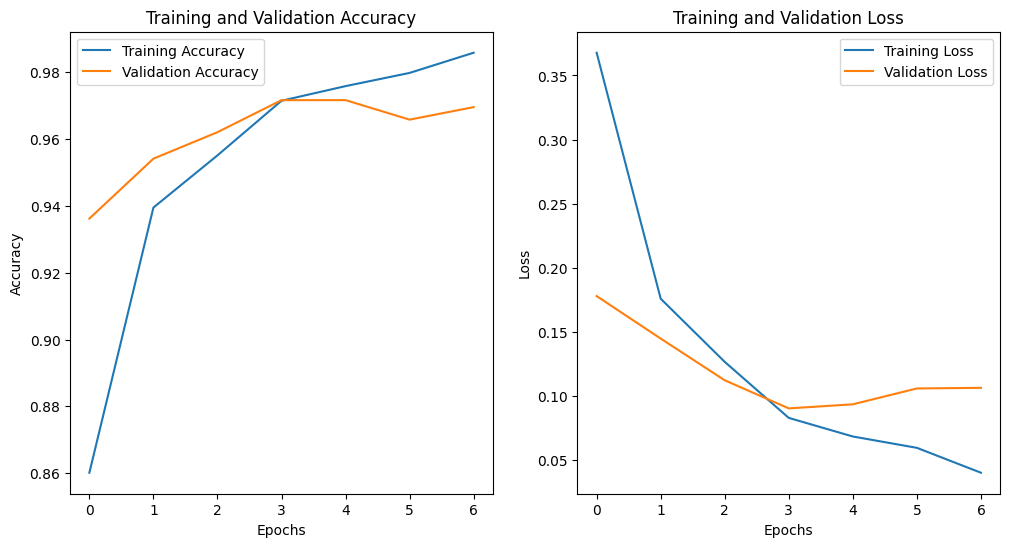

In [31]:
import matplotlib.pyplot as plt

# Plotting training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


## Konversi Model

In [32]:
# Menyimpan model dalam format Keras (.keras)
model.save('model.keras')  

# Menyimpan model dalam format TF-Lite
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TFLite ke file
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

# Menyimpan model dalam format TensorFlow.js
!pip install tensorflowjs
import tensorflowjs as tfjs

tfjs.converters.save_keras_model(model, 'model_tfjs')

Saved artifact at '/tmp/tmpy4joq32m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132657085054608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657085052496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657085050192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657085054416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657078846480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657078845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657078846672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657078852240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657078851472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132657078853776: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1745922226.287511      31 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1745922226.287554      31 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


failed to lookup keras version from the file,
    this is likely a weight only file


## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


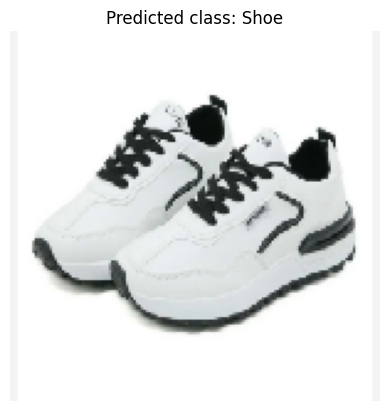

Predicted class (keras model): Shoe


In [19]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

labels = ['Boot', 'Sandal', 'Shoe']  

# Load model
model_keras = load_model('model.keras')

# Load dan preprocessing 1 gambar untuk prediksi
img_path = '/kaggle/input/screenshot-2025-04-28-222702-png/Screenshot 2025-04-28 222702.png'
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  
img_array /= 255.0  

# Prediksi
predictions = model_keras.predict(img_array)
predicted_class = np.argmax(predictions)

# Menampilkan gambar dengan nama kelas prediksi
plt.imshow(img)
plt.axis('off')  
plt.title(f"Predicted class: {labels[predicted_class]}")  
plt.show()

print(f"Predicted class (keras model): {labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


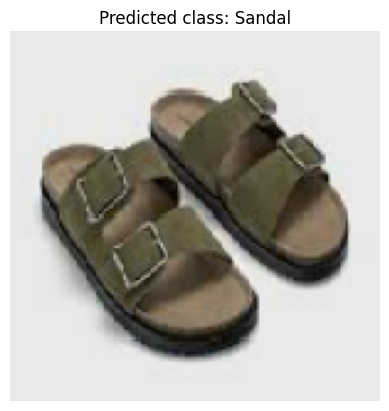

Predicted class (keras model): Sandal


In [20]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

labels = ['Boot', 'Sandal', 'Shoe'] 

# Load model
model_keras = load_model('model.keras')

# Load dan preprocessing 1 gambar untuk prediksi
img_path = '/kaggle/input/screenshot-2025-04-28-224951-png/Screenshot 2025-04-28 224951.png'
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  
img_array /= 255.0  

# Prediksi
predictions = model_keras.predict(img_array)
predicted_class = np.argmax(predictions)

# Menampilkan gambar dengan nama kelas prediksi
plt.imshow(img)
plt.axis('off')  
plt.title(f"Predicted class: {labels[predicted_class]}")  
plt.show()

print(f"Predicted class (keras model): {labels[predicted_class]}")


In [21]:
!pip freeze > requirements.txt

In [22]:
!cat requirements.txt

absl-py==1.4.0
accelerate==1.3.0
aiofiles==22.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.16
aiosignal==1.3.2
aiosqlite==0.21.0
alabaster==1.0.0
albucore==0.0.23
albumentations==2.0.4
ale-py==0.10.1
alembic==1.15.2
altair==5.5.0
annotated-types==0.7.0
annoy==1.17.3
ansicolors==1.1.8
antlr4-python3-runtime==4.9.3
anyio==3.7.1
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
args==0.1.0
array_record==0.6.0
arrow==1.3.0
arviz==0.20.0
astropy==7.0.1
astropy-iers-data==0.2025.2.10.0.33.26
asttokens==3.0.0
astunparse==1.6.3
atpublic==4.1.0
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
bayesian-optimization==2.0.3
beartype==0.20.2
beautifulsoup4==4.13.3
betterproto==2.0.0b6
bigframes==1.36.0
bigquery-magics==0.5.0
bleach==6.2.0
blinker==1.9.0
blis==0.7.11
blobfile==3.0.0
blosc2==3.1.0
bokeh==3.6.3
Boruta==0.4.3
boto3==1.37.29
botocore==1.37.29
Bottleneck==1.4.2
-e git+https://github.com/SohierDane/BigQuery_Helper@8615a7f6c1663e7f2d48aa2b32c2dbcb600a440f#egg=bq_hel